## Análise de Correlação & Regressão Linear Simples

In [2]:
# Importa bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

In [3]:
Preço = [1.3, 2.0, 1.7, 1.5, 1.6, 1.2, 1.6, 1.4, 1.0, 1.1]
Vendas =[10, 6, 5, 12, 10, 15, 5, 12, 17, 20]
df = pd.DataFrame(list(zip(Preço, Vendas)), columns =['Preço','Vendas'])       
print(df)

   Preço  Vendas
0    1.3      10
1    2.0       6
2    1.7       5
3    1.5      12
4    1.6      10
5    1.2      15
6    1.6       5
7    1.4      12
8    1.0      17
9    1.1      20


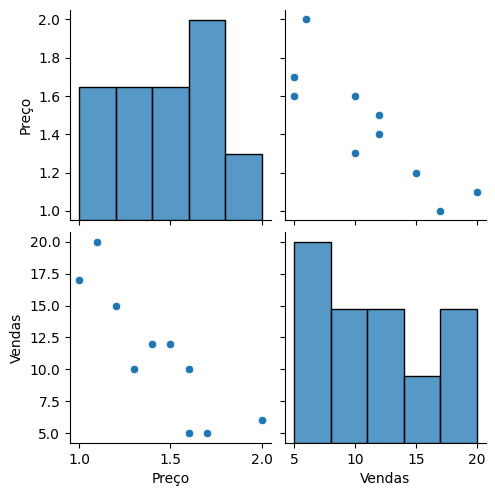

In [4]:
# Mostra a correção entre as variáveis
sns.pairplot(df)

In [5]:
corr = df.corr()
print(corr)

           Preço    Vendas
Preço   1.000000 -0.863489
Vendas -0.863489  1.000000


In [6]:
corr_Preço_Vendas = np.corrcoef(df.Preço, df.Vendas)[0,1]
print("Correlação entre Preço e Vendas: {:.3f}".format(corr_Preço_Vendas))

Correlação entre Preço e Vendas: -0.863


Text(0.5, 1.0, 'Correlação entre Preço e Vendas: r=-0.863')

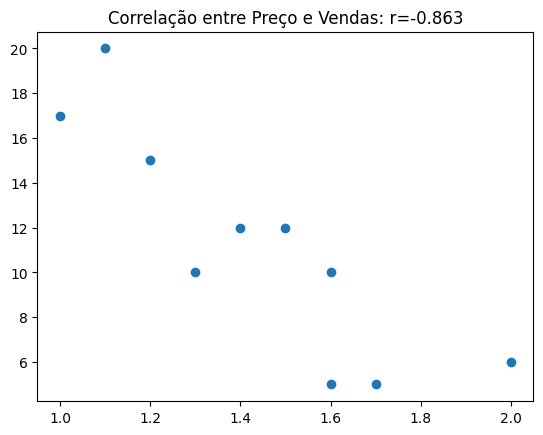

In [7]:
# Visualizar a correlação entre Preço e Vendas
plt.scatter(df['Preço'], df['Vendas'])
plt.title("Correlação entre Preço e Vendas: r={:.3f}".format(corr_Preço_Vendas))

In [9]:
# Importa biblioteca
from sklearn.linear_model import LinearRegression

# Variáveis do problema (arrays)
# reshape(-1,1) para transformar em uma matriz n x 1 (em caso contrário, será uma matriz 1 x n).
pre = df['Preço'].values.reshape(-1,1)
ven = df['Vendas'].values.reshape(-1,1)

# Inicializa a realiza a regressão
model_lr = LinearRegression()
model_lr.fit(pre, ven)

# Mostra o modelo de regressão
print('Coeficiente de regressão: %.3f' %model_lr.coef_)
print('Intercepta: %.3f' %model_lr.intercept_)
print('Equação de regressão: y= %.3fx + %.3f' % (model_lr.coef_ , model_lr.intercept_))

# Imprime R^2
print("R^2 = {:.3f}".format(model_lr.score(pre, ven)))

ModuleNotFoundError: No module named 'sklearn'

C:\Users\Andre\AppData\Local\Temp\ipykernel_8700\366110901.py:3: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  plt.title("Análise de Regressão \n y= %.3fx + %.3f \n R2 = %.3f" %


Text(0.5, 1.0, 'Análise de Regressão \n y= -14.539x + 32.136 \n R2 = 0.746')

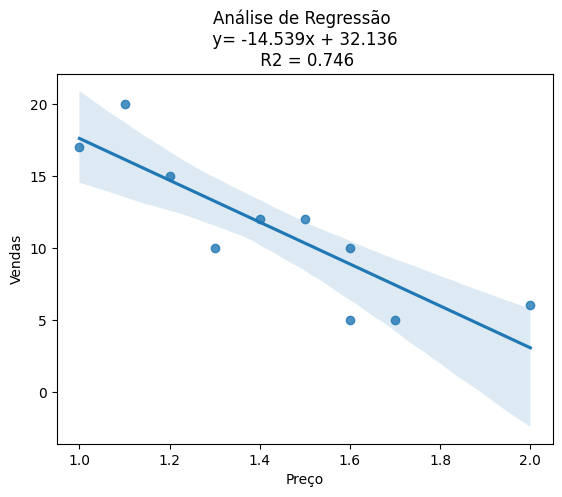

In [8]:
# Visualiza a Regressão Linear Simpels
sns.regplot(x="Preço", y="Vendas", data=df, ci=95)
plt.title("Análise de Regressão \n y= %.3fx + %.3f \n R2 = %.3f" %
          (model_lr.coef_ , model_lr.intercept_, model_lr.score(pre, ven)))

In [10]:
# Importa as Bibliotecas
import statsmodels.api as sm
from statsmodels.formula.api import ols

In [11]:
# Regressão - Variável Independente Preço
model_1 = ols('Vendas ~ Preço', df).fit()
print(model_1.summary())

                            OLS Regression Results                            
Dep. Variable:                 Vendas   R-squared:                       0.746
Model:                            OLS   Adj. R-squared:                  0.714
Method:                 Least Squares   F-statistic:                     23.45
Date:                Tue, 23 Sep 2025   Prob (F-statistic):            0.00128
Time:                        09:25:37   Log-Likelihood:                -23.100
No. Observations:                  10   AIC:                             50.20
Df Residuals:                       8   BIC:                             50.81
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     32.1359      4.409      7.289      0.0

c:\Users\Andre\miniconda3\envs\OIL_GAS\Lib\site-packages\scipy\stats\_axis_nan_policy.py:418: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=10 observations were given.
  return hypotest_fun_in(*args, **kwds)


In [12]:
import scipy.stats
scipy.stats.t.ppf(0.025, 8)

np.float64(-2.3060041352041662)

## Regressão Linear Multivariada

In [2]:
# Importa bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

In [3]:
Preço = [1.3, 2.0, 1.7, 1.5, 1.6, 1.2, 1.6, 1.4, 1.0, 1.1]
Publicidade = [9.0, 7.0, 5.0, 14.0, 15.0, 12.0, 6.0, 10.0, 15.0, 21.0]
Vendas = [10, 6, 5, 12, 10, 15, 5, 12, 17, 20]
df = pd.DataFrame(list(zip(Preço, Publicidade, Vendas)), columns =['Preço','Publicidade','Vendas'])       
print(df)

   Preço  Publicidade  Vendas
0    1.3          9.0      10
1    2.0          7.0       6
2    1.7          5.0       5
3    1.5         14.0      12
4    1.6         15.0      10
5    1.2         12.0      15
6    1.6          6.0       5
7    1.4         10.0      12
8    1.0         15.0      17
9    1.1         21.0      20


In [4]:
corr = df.corr()
print(corr)

                Preço  Publicidade    Vendas
Preço        1.000000    -0.654490 -0.863489
Publicidade -0.654490     1.000000  0.891497
Vendas      -0.863489     0.891497  1.000000


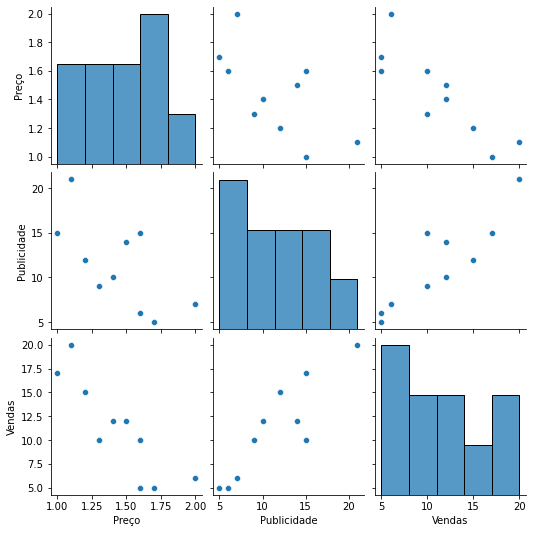

In [5]:
# Mostra a correção entre as variáveis
sns.pairplot(df)

In [6]:
corr_Publicidade_Vendas = np.corrcoef(df.Publicidade, df.Vendas)[0,1]
print("Correlação entre Publicidade e Vendas: {:.3f}".format(corr_Publicidade_Vendas))

Correlação entre Publicidade e Vendas: 0.891


Text(0.5, 1.0, 'Correlação entre Publicidade e Vendas: r=0.891')

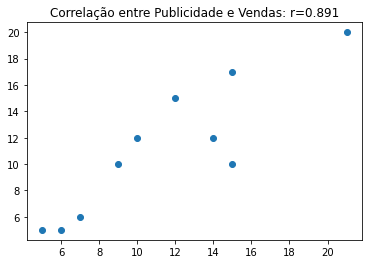

In [7]:
# Visualizar a correlação entre Preço e Vendas
plt.scatter(df['Publicidade'], df['Vendas'])
plt.title("Correlação entre Publicidade e Vendas: r={:.3f}".format(corr_Publicidade_Vendas))

In [9]:
# Importa as Bibliotecas
import statsmodels.api as sm
from statsmodels.formula.api import ols

# Regressão - Variável Independente Preço
model_1 = ols('Vendas ~ Preço + Publicidade', df).fit()
print(model_1.summary())

                            OLS Regression Results                            
Dep. Variable:                 Vendas   R-squared:                       0.932
Model:                            OLS   Adj. R-squared:                  0.912
Method:                 Least Squares   F-statistic:                     47.92
Date:                Mon, 24 Oct 2022   Prob (F-statistic):           8.23e-05
Time:                        18:50:40   Log-Likelihood:                -16.509
No. Observations:                  10   AIC:                             39.02
Df Residuals:                       7   BIC:                             39.92
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept      16.4064      4.343      3.778      

C:\Users\andre\anaconda3\lib\site-packages\scipy\stats\stats.py:1603: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=10
  warnings.warn("kurtosistest only valid for n>=20 ... continuing "


In [10]:
Renda = [11, 3, 4, 7, 9, 8, 5, 7, 8, 7]
Tamanho = [6, 2, 1, 3, 5, 4, 2, 2, 3, 2]
Gasto = [24, 8, 16, 18, 24, 23, 11, 15, 21, 20]
df = pd.DataFrame(list(zip(Renda, Tamanho, Gasto)), columns =['Renda','Tamanho','Gasto'])       
print(df)

   Renda  Tamanho  Gasto
0     11        6     24
1      3        2      8
2      4        1     16
3      7        3     18
4      9        5     24
5      8        4     23
6      5        2     11
7      7        2     15
8      8        3     21
9      7        2     20


In [11]:
corr = df.corr()
print(corr)

            Renda   Tamanho     Gasto
Renda    1.000000  0.866618  0.883873
Tamanho  0.866618  1.000000  0.736850
Gasto    0.883873  0.736850  1.000000


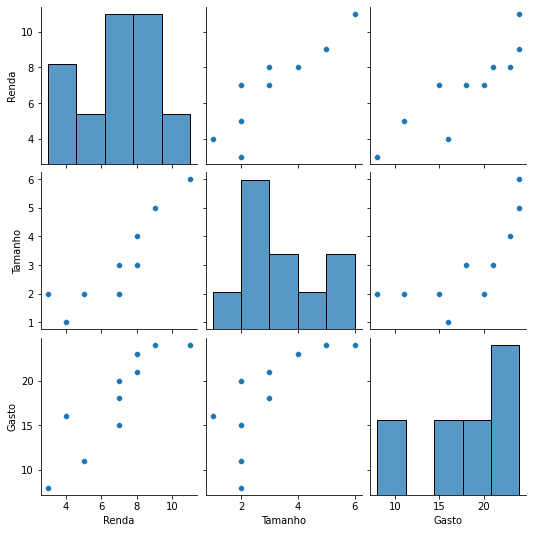

In [12]:
# Mostra a correção entre as variáveis
sns.pairplot(df)

In [13]:
# Importa as Bibliotecas
import statsmodels.api as sm
from statsmodels.formula.api import ols

# Regressão - Variável Independente Preço
model_1 = ols('Gasto ~ Renda + Tamanho', df).fit()
print(model_1.summary())

                            OLS Regression Results                            
Dep. Variable:                  Gasto   R-squared:                       0.785
Model:                            OLS   Adj. R-squared:                  0.723
Method:                 Least Squares   F-statistic:                     12.75
Date:                Mon, 24 Oct 2022   Prob (F-statistic):            0.00464
Time:                        19:19:45   Log-Likelihood:                -23.028
No. Observations:                  10   AIC:                             52.06
Df Residuals:                       7   BIC:                             52.96
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      3.5187      3.161      1.113      0.3

C:\Users\andre\anaconda3\lib\site-packages\scipy\stats\stats.py:1603: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=10
  warnings.warn("kurtosistest only valid for n>=20 ... continuing "


In [15]:

Teste = [10, 19, 27, 31, 64, 81, 42, 67, 48, 64, 57, 10, 48, 96, 75, 12, 47, 20, 73, 4, 9, 98, 27, 59, 23, 90, 34, 16, 32, 94]
Idade = [21.1, 22.5, 23.1, 24.0, 22.6, 21.7, 23.8, 22.0, 22.4, 22.6, 21.1, 22.5, 22.2, 24.8, 22.6, 20.5, 21.9, 20.5, 20.8, 20.0, 23.3, 21.3, 22.9, 22.3, 22.6, 22.4, 23.8, 20.6, 24.4, 25.0]
Ansiedade = [4.9, 3.0, 1.5, 0.6, 1.8, 3.3, 3.2, 2.1, 6.0, 1.8, 3.8, 4.5, 4.5, 0.1, 0.9, 4.8, 2.3, 3.0, 0.3, 2.7, 4.4, 3.9, 1.4, 2.7, 2.7, 2.2, 0.7, 3.1, 0.6, 4.6]
Experiencia = [0, 1, 0, 3, 2, 1, 0, 0, 1, 1, 0, 1, 0, 3, 0, 0, 1, 2, 2, 0, 1, 1, 2, 1, 1, 2, 1, 1, 3, 5]
Media = [2.4, 2.6, 2.8, 2.7, 2.0, 2.5, 2.5, 2.3, 2.8, 3.4, 3.0, 2.7, 2.8, 3.8, 3.7, 2.1, 1.8, 1.5, 1.9, 2.2, 2.8, 2.9, 3.2, 2.7, 2.4, 2.6, 3.4, 2.3, 4.0, 3.6]
Vendas = [44, 47, 60, 71, 61, 60, 58, 56, 66, 61, 51, 47, 53, 74, 65, 33, 54, 39, 52, 30, 58, 59, 52, 56, 49, 63, 61, 39, 62, 78]

df1 = pd.DataFrame(list(zip(Teste, Idade, Ansiedade, Experiencia, Media, Vendas)), columns =['Teste','Idade','Ansiedade','Experiencia','Media','Vendas'])
print(df1)


    Teste  Idade  Ansiedade  Experiencia  Media  Vendas
0      10   21.1        4.9            0    2.4      44
1      19   22.5        3.0            1    2.6      47
2      27   23.1        1.5            0    2.8      60
3      31   24.0        0.6            3    2.7      71
4      64   22.6        1.8            2    2.0      61
5      81   21.7        3.3            1    2.5      60
6      42   23.8        3.2            0    2.5      58
7      67   22.0        2.1            0    2.3      56
8      48   22.4        6.0            1    2.8      66
9      64   22.6        1.8            1    3.4      61
10     57   21.1        3.8            0    3.0      51
11     10   22.5        4.5            1    2.7      47
12     48   22.2        4.5            0    2.8      53
13     96   24.8        0.1            3    3.8      74
14     75   22.6        0.9            0    3.7      65
15     12   20.5        4.8            0    2.1      33
16     47   21.9        2.3            1    1.8 

In [16]:
corr = df1.corr()
print(corr)

                Teste     Idade  Ansiedade  Experiencia     Media    Vendas
Teste        1.000000  0.256649  -0.221988     0.349639  0.317772  0.676120
Idade        0.256649  1.000000  -0.319224     0.557595  0.696922  0.811956
Ansiedade   -0.221988 -0.319224   1.000000    -0.278689 -0.244382 -0.295860
Experiencia  0.349639  0.557595  -0.278689     1.000000  0.312129  0.549834
Media        0.317772  0.696922  -0.244382     0.312129  1.000000  0.621784
Vendas       0.676120  0.811956  -0.295860     0.549834  0.621784  1.000000


In [18]:
# Importa as Bibliotecas
import statsmodels.api as sm
from statsmodels.formula.api import ols

# Regressão - Variável Independente Teste
model_1 = ols('Vendas ~ Teste', df1).fit()
print(model_1.summary())

                            OLS Regression Results                            
Dep. Variable:                 Vendas   R-squared:                       0.457
Model:                            OLS   Adj. R-squared:                  0.438
Method:                 Least Squares   F-statistic:                     23.58
Date:                Mon, 24 Oct 2022   Prob (F-statistic):           4.11e-05
Time:                        20:31:15   Log-Likelihood:                -105.28
No. Observations:                  30   AIC:                             214.6
Df Residuals:                      28   BIC:                             217.4
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     43.4120      2.886     15.041      0.0

In [19]:
# Regressão - Variável Independente Idade
model_1 = ols('Vendas ~ Idade', df1).fit()
print(model_1.summary())

                            OLS Regression Results                            
Dep. Variable:                 Vendas   R-squared:                       0.659
Model:                            OLS   Adj. R-squared:                  0.647
Method:                 Least Squares   F-statistic:                     54.18
Date:                Mon, 24 Oct 2022   Prob (F-statistic):           5.15e-08
Time:                        20:31:25   Log-Likelihood:                -98.298
No. Observations:                  30   AIC:                             200.6
Df Residuals:                      28   BIC:                             203.4
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   -100.7317     21.233     -4.744      0.0

In [20]:
# Regressão - Variável Independente Ansiedade
model_1 = ols('Vendas ~ Ansiedade', df1).fit()
print(model_1.summary())

                            OLS Regression Results                            
Dep. Variable:                 Vendas   R-squared:                       0.088
Model:                            OLS   Adj. R-squared:                  0.055
Method:                 Least Squares   F-statistic:                     2.686
Date:                Mon, 24 Oct 2022   Prob (F-statistic):              0.112
Time:                        20:31:37   Log-Likelihood:                -113.07
No. Observations:                  30   AIC:                             230.1
Df Residuals:                      28   BIC:                             233.0
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     61.0367      4.022     15.174      0.0

In [21]:
# Regressão - Variável Independente Experiencia
model_1 = ols('Vendas ~ Experiencia', df1).fit()
print(model_1.summary())

                            OLS Regression Results                            
Dep. Variable:                 Vendas   R-squared:                       0.302
Model:                            OLS   Adj. R-squared:                  0.277
Method:                 Least Squares   F-statistic:                     12.13
Date:                Mon, 24 Oct 2022   Prob (F-statistic):            0.00165
Time:                        20:31:58   Log-Likelihood:                -109.05
No. Observations:                  30   AIC:                             222.1
Df Residuals:                      28   BIC:                             224.9
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept      49.0882      2.487     19.740      

In [22]:
# Regressão - Variável Independente Media
model_1 = ols('Vendas ~ Media', df1).fit()
print(model_1.summary())

                            OLS Regression Results                            
Dep. Variable:                 Vendas   R-squared:                       0.387
Model:                            OLS   Adj. R-squared:                  0.365
Method:                 Least Squares   F-statistic:                     17.65
Date:                Mon, 24 Oct 2022   Prob (F-statistic):           0.000245
Time:                        20:32:01   Log-Likelihood:                -107.12
No. Observations:                  30   AIC:                             218.2
Df Residuals:                      28   BIC:                             221.0
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     24.2765      7.561      3.211      0.0

In [23]:
# Regressão - Variável Independente Idade
model_1 = ols('Vendas ~ Idade + Teste', df1).fit()
print(model_1.summary())

                            OLS Regression Results                            
Dep. Variable:                 Vendas   R-squared:                       0.893
Model:                            OLS   Adj. R-squared:                  0.886
Method:                 Least Squares   F-statistic:                     113.2
Date:                Mon, 24 Oct 2022   Prob (F-statistic):           7.43e-14
Time:                        20:43:07   Log-Likelihood:                -80.858
No. Observations:                  30   AIC:                             167.7
Df Residuals:                      27   BIC:                             171.9
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    -84.8405     12.265     -6.917      0.0

In [24]:
# Regressão - Variável Independente Idade
model_1 = ols('Vendas ~ Idade + Ansiedade', df1).fit()
print(model_1.summary())

                            OLS Regression Results                            
Dep. Variable:                 Vendas   R-squared:                       0.661
Model:                            OLS   Adj. R-squared:                  0.636
Method:                 Least Squares   F-statistic:                     26.30
Date:                Mon, 24 Oct 2022   Prob (F-statistic):           4.59e-07
Time:                        20:44:28   Log-Likelihood:                -98.232
No. Observations:                  30   AIC:                             202.5
Df Residuals:                      27   BIC:                             206.7
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    -97.4358     23.594     -4.130      0.0

In [25]:
# Regressão - Variável Independente Idade
model_1 = ols('Vendas ~ Idade + Experiencia', df1).fit()
print(model_1.summary())

                            OLS Regression Results                            
Dep. Variable:                 Vendas   R-squared:                       0.673
Model:                            OLS   Adj. R-squared:                  0.649
Method:                 Least Squares   F-statistic:                     27.78
Date:                Mon, 24 Oct 2022   Prob (F-statistic):           2.80e-07
Time:                        20:56:57   Log-Likelihood:                -97.684
No. Observations:                  30   AIC:                             201.4
Df Residuals:                      27   BIC:                             205.6
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept     -87.2260     24.704     -3.531      

In [26]:
# Regressão - Variável Independente Idade
model_1 = ols('Vendas ~ Idade + Media', df1).fit()
print(model_1.summary())

                            OLS Regression Results                            
Dep. Variable:                 Vendas   R-squared:                       0.665
Model:                            OLS   Adj. R-squared:                  0.641
Method:                 Least Squares   F-statistic:                     26.84
Date:                Mon, 24 Oct 2022   Prob (F-statistic):           3.82e-07
Time:                        20:57:56   Log-Likelihood:                -98.028
No. Observations:                  30   AIC:                             202.1
Df Residuals:                      27   BIC:                             206.3
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    -91.5958     25.087     -3.651      0.0

In [27]:
# Regressão
model_1 = ols('Vendas ~ Idade + Teste + Ansiedade', df1).fit()
print(model_1.summary())

                            OLS Regression Results                            
Dep. Variable:                 Vendas   R-squared:                       0.895
Model:                            OLS   Adj. R-squared:                  0.883
Method:                 Least Squares   F-statistic:                     73.68
Date:                Mon, 24 Oct 2022   Prob (F-statistic):           7.73e-13
Time:                        20:59:50   Log-Likelihood:                -80.677
No. Observations:                  30   AIC:                             169.4
Df Residuals:                      26   BIC:                             175.0
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    -87.7393     13.453     -6.522      0.0

In [28]:
# Regressão
model_1 = ols('Vendas ~ Idade + Teste + Experiencia', df1).fit()
print(model_1.summary())

                            OLS Regression Results                            
Dep. Variable:                 Vendas   R-squared:                       0.894
Model:                            OLS   Adj. R-squared:                  0.881
Method:                 Least Squares   F-statistic:                     72.74
Date:                Mon, 24 Oct 2022   Prob (F-statistic):           8.97e-13
Time:                        21:01:34   Log-Likelihood:                -80.849
No. Observations:                  30   AIC:                             169.7
Df Residuals:                      26   BIC:                             175.3
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept     -85.7134     14.365     -5.967      

In [29]:
# Regressão
model_1 = ols('Vendas ~ Idade + Teste + Media', df1).fit()
print(model_1.summary())

                            OLS Regression Results                            
Dep. Variable:                 Vendas   R-squared:                       0.894
Model:                            OLS   Adj. R-squared:                  0.882
Method:                 Least Squares   F-statistic:                     72.98
Date:                Mon, 24 Oct 2022   Prob (F-statistic):           8.63e-13
Time:                        21:02:45   Log-Likelihood:                -80.805
No. Observations:                  30   AIC:                             169.6
Df Residuals:                      26   BIC:                             175.2
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    -87.0317     14.411     -6.039      0.0

In [24]:
# Importa bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

In [25]:
Renda = [273.4, 291.3, 306.9, 317.1, 336.1, 349.4, 362.9, 383.9, 402.8, 437.0, 472.2, 510.4, 544.5, 588.1, 630.4, 685.9, 742.8, 801.3, 903.1, 983.6, 1076.7]
Venda = [295, 400, 390, 425, 547, 555, 620, 720, 880, 1050, 1290, 1528, 1586, 1960, 2118, 2116, 2477, 3199, 3702, 3316, 2702]
df = pd.DataFrame(list(zip(Renda, Venda)), columns =['Renda','Venda'])       
print(df)

     Renda  Venda
0    273.4    295
1    291.3    400
2    306.9    390
3    317.1    425
4    336.1    547
5    349.4    555
6    362.9    620
7    383.9    720
8    402.8    880
9    437.0   1050
10   472.2   1290
11   510.4   1528
12   544.5   1586
13   588.1   1960
14   630.4   2118
15   685.9   2116
16   742.8   2477
17   801.3   3199
18   903.1   3702
19   983.6   3316
20  1076.7   2702


In [4]:
corr = df.corr()
print(corr)

          Renda     Venda
Renda  1.000000  0.951319
Venda  0.951319  1.000000


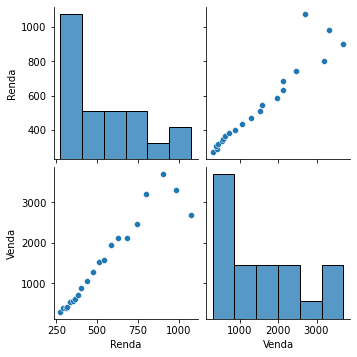

In [5]:
# Mostra a correção entre as variáveis
sns.pairplot(df)

In [26]:
# Importa as Bibliotecas
import statsmodels.api as sm
from statsmodels.formula.api import ols

# Regressão - Variável Independente Renda
model_1 = ols('Venda ~ Renda', df).fit()
print(model_1.summary())

                            OLS Regression Results                            
Dep. Variable:                  Venda   R-squared:                       0.905
Model:                            OLS   Adj. R-squared:                  0.900
Method:                 Least Squares   F-statistic:                     181.0
Date:                Mon, 21 Nov 2022   Prob (F-statistic):           3.67e-11
Time:                        20:41:07   Log-Likelihood:                -151.22
No. Observations:                  21   AIC:                             306.4
Df Residuals:                      19   BIC:                             308.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   -792.0024    187.128     -4.232      0.0

In [27]:
from statsmodels.stats.stattools import durbin_watson

#realiza o teste Durbin-Watson
durbin_watson(model_1.resid)

0.8712532014949105

In [28]:
Renda = [336.1, 349.4, 362.9, 383.9, 402.8, 437.0, 472.2, 510.4, 544.5, 588.1, 630.4, 685.9, 742.8, 801.3, 903.1, 983.6, 1076.7]
Venda = [8.0, 8.2, 8.5, 9.2, 10.2, 11.4, 12.8, 13.6, 14.6, 16.4, 17.8, 18.6, 20.0, 21.9, 24.9, 27.3, 29.1]
df = pd.DataFrame(list(zip(Renda, Venda)), columns =['Renda','Venda'])       
print(df)

     Renda  Venda
0    336.1    8.0
1    349.4    8.2
2    362.9    8.5
3    383.9    9.2
4    402.8   10.2
5    437.0   11.4
6    472.2   12.8
7    510.4   13.6
8    544.5   14.6
9    588.1   16.4
10   630.4   17.8
11   685.9   18.6
12   742.8   20.0
13   801.3   21.9
14   903.1   24.9
15   983.6   27.3
16  1076.7   29.1


In [29]:
corr = df.corr()
print(corr)

          Renda     Venda
Renda  1.000000  0.997693
Venda  0.997693  1.000000


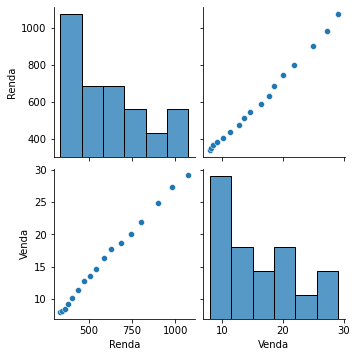

In [30]:
# Mostra a correção entre as variáveis
sns.pairplot(df)

In [31]:
# Importa as Bibliotecas
import statsmodels.api as sm
from statsmodels.formula.api import ols

# Regressão - Variável Independente Renda
model_2 = ols('Venda ~ Renda', df).fit()
print(model_2.summary())

                            OLS Regression Results                            
Dep. Variable:                  Venda   R-squared:                       0.995
Model:                            OLS   Adj. R-squared:                  0.995
Method:                 Least Squares   F-statistic:                     3240.
Date:                Mon, 21 Nov 2022   Prob (F-statistic):           6.08e-19
Time:                        20:44:59   Log-Likelihood:                -10.462
No. Observations:                  17   AIC:                             24.92
Df Residuals:                      15   BIC:                             26.59
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -1.5046      0.329     -4.573      0.0

C:\Users\andre\anaconda3\lib\site-packages\scipy\stats\stats.py:1603: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=17
  warnings.warn("kurtosistest only valid for n>=20 ... continuing "


In [32]:
from statsmodels.stats.stattools import durbin_watson

#realiza o teste Durbin-Watson
durbin_watson(model_2.resid)

0.7218064442510285

In [33]:
Renda = [336.1, 349.4, 362.9, 383.9, 402.8, 437.0, 472.2, 510.4, 544.5, 588.1, 630.4, 685.9, 742.8, 801.3, 903.1, 983.6, 1076.7]
Taxa = [5.5, 5.5, 6.7, 5.5, 5.7, 5.2, 4.5, 3.8, 3.8, 3.6, 3.5, 4.9, 5.9, 5.6, 4.9, 5.6, 8.5]
Venda = [8.0, 8.2, 8.5, 9.2, 10.2, 11.4, 12.8, 13.6, 14.6, 16.4, 17.8, 18.6, 20.0, 21.9, 24.9, 27.3, 29.1]
df = pd.DataFrame(list(zip(Renda, Taxa, Venda)), columns =['Renda','Taxa','Venda'])       
print(df)

     Renda  Taxa  Venda
0    336.1   5.5    8.0
1    349.4   5.5    8.2
2    362.9   6.7    8.5
3    383.9   5.5    9.2
4    402.8   5.7   10.2
5    437.0   5.2   11.4
6    472.2   4.5   12.8
7    510.4   3.8   13.6
8    544.5   3.8   14.6
9    588.1   3.6   16.4
10   630.4   3.5   17.8
11   685.9   4.9   18.6
12   742.8   5.9   20.0
13   801.3   5.6   21.9
14   903.1   4.9   24.9
15   983.6   5.6   27.3
16  1076.7   8.5   29.1


In [34]:
corr = df.corr()
print(corr)

          Renda      Taxa     Venda
Renda  1.000000  0.299212  0.997693
Taxa   0.299212  1.000000  0.240537
Venda  0.997693  0.240537  1.000000


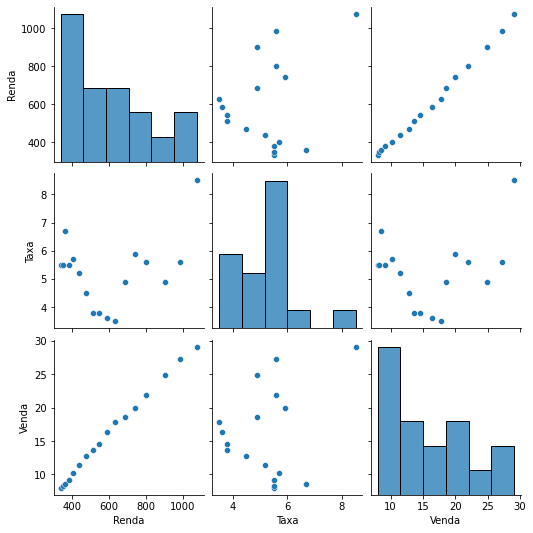

In [35]:
# Mostra a correção entre as variáveis
sns.pairplot(df)

In [36]:
# Importa as Bibliotecas
import statsmodels.api as sm
from statsmodels.formula.api import ols

# Regressão - Variável Independente Renda
model_2b = ols('Venda ~ Renda + Taxa', df).fit()
print(model_2b.summary())

                            OLS Regression Results                            
Dep. Variable:                  Venda   R-squared:                       0.999
Model:                            OLS   Adj. R-squared:                  0.999
Method:                 Least Squares   F-statistic:                     7638.
Date:                Mon, 21 Nov 2022   Prob (F-statistic):           5.40e-22
Time:                        20:47:08   Log-Likelihood:                 3.2740
No. Observations:                  17   AIC:                           -0.5479
Df Residuals:                      14   BIC:                             1.952
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.0140      0.250     -0.056      0.9

C:\Users\andre\anaconda3\lib\site-packages\scipy\stats\stats.py:1603: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=17
  warnings.warn("kurtosistest only valid for n>=20 ... continuing "


In [37]:
from statsmodels.stats.stattools import durbin_watson

#realiza o teste Durbin-Watson
durbin_watson(model_2b.resid)

1.9800332212843381

In [38]:
Renda = [273.4, 291.3, 306.9, 317.1, 336.1, 349.4, 362.9, 383.9, 402.8, 437.0, 472.2, 510.4, 544.5, 588.1, 630.4, 685.9, 742.8, 801.3, 903.1, 983.6, 1076.7]
Venda = [3307, 3556, 3601, 3721, 4036, 4134, 4268, 4758, 5093, 5716, 6357, 6769, 7296, 8178, 8844, 9251, 10006, 11200, 12500, 13101, 13640]
df = pd.DataFrame(list(zip(Renda, Venda)), columns =['Renda','Venda'])       
print(df)

     Renda  Venda
0    273.4   3307
1    291.3   3556
2    306.9   3601
3    317.1   3721
4    336.1   4036
5    349.4   4134
6    362.9   4268
7    383.9   4758
8    402.8   5093
9    437.0   5716
10   472.2   6357
11   510.4   6769
12   544.5   7296
13   588.1   8178
14   630.4   8844
15   685.9   9251
16   742.8  10006
17   801.3  11200
18   903.1  12500
19   983.6  13101
20  1076.7  13640


In [39]:
corr = df.corr()
print(corr)

          Renda     Venda
Renda  1.000000  0.995297
Venda  0.995297  1.000000


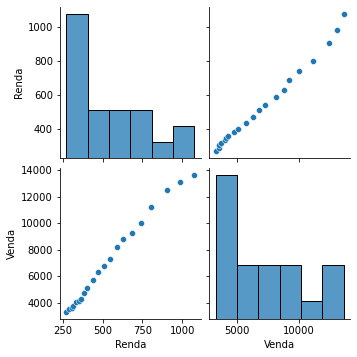

In [40]:
# Mostra a correção entre as variáveis
sns.pairplot(df)

In [41]:
# Importa as Bibliotecas
import statsmodels.api as sm
from statsmodels.formula.api import ols

# Regressão - Variável Independente Renda
model_3 = ols('Venda ~ Renda', df).fit()
print(model_3.summary())

                            OLS Regression Results                            
Dep. Variable:                  Venda   R-squared:                       0.991
Model:                            OLS   Adj. R-squared:                  0.990
Method:                 Least Squares   F-statistic:                     2006.
Date:                Mon, 21 Nov 2022   Prob (F-statistic):           9.91e-21
Time:                        20:48:43   Log-Likelihood:                -151.01
No. Observations:                  21   AIC:                             306.0
Df Residuals:                      19   BIC:                             308.1
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   -502.4086    185.280     -2.712      0.0

In [42]:
from statsmodels.stats.stattools import durbin_watson

#realiza o teste Durbin-Watson
durbin_watson(model_3.resid)

0.6403663650726367

In [43]:
Renda1 = [119.8, 124.2, 124.6, 137.2, 138.6, 143.7, 156.3, 162.0, 184.3, 198.1, 214.2, 224.4, 246.6, 261.5, 290.5, 312.6, 335.4, 400.5, 417.1, 459.7]
Venda1 = [1481.7, 1370.5, 1462.3, 1702.0, 1602.4, 1675.0, 2080.9, 2108.6, 2521.4, 2771.7, 2781.6, 3050.2, 3601.6, 3714.4, 3703.6, 4203.3, 4923.8, 5474.8, 5260.4, 5422.4]
df1 = pd.DataFrame(list(zip(Renda1, Venda1)), columns =['Renda1','Venda1'])       
print(df1)

    Renda1  Venda1
0    119.8  1481.7
1    124.2  1370.5
2    124.6  1462.3
3    137.2  1702.0
4    138.6  1602.4
5    143.7  1675.0
6    156.3  2080.9
7    162.0  2108.6
8    184.3  2521.4
9    198.1  2771.7
10   214.2  2781.6
11   224.4  3050.2
12   246.6  3601.6
13   261.5  3714.4
14   290.5  3703.6
15   312.6  4203.3
16   335.4  4923.8
17   400.5  5474.8
18   417.1  5260.4
19   459.7  5422.4


In [44]:
corr = df1.corr()
print(corr)

          Renda1    Venda1
Renda1  1.000000  0.983784
Venda1  0.983784  1.000000


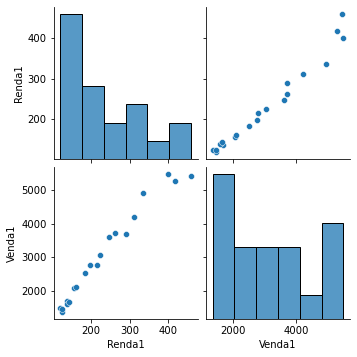

In [45]:
# Mostra a correção entre as variáveis
sns.pairplot(df1)

In [46]:
# Importa as Bibliotecas
import statsmodels.api as sm
from statsmodels.formula.api import ols

# Regressão - Variável Independente Renda
model_3b = ols('Venda1 ~ Renda1', df1).fit()
print(model_3b.summary())

                            OLS Regression Results                            
Dep. Variable:                 Venda1   R-squared:                       0.968
Model:                            OLS   Adj. R-squared:                  0.966
Method:                 Least Squares   F-statistic:                     541.6
Date:                Mon, 21 Nov 2022   Prob (F-statistic):           6.94e-15
Time:                        20:50:01   Log-Likelihood:                -138.65
No. Observations:                  20   AIC:                             281.3
Df Residuals:                      18   BIC:                             283.3
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    -29.1691    144.490     -0.202      0.8

In [47]:
from statsmodels.stats.stattools import durbin_watson

#realiza o teste Durbin-Watson
durbin_watson(model_3b.resid)

0.8817811116243258

In [48]:
X = [85.54, 85.54, 85.63, 85.08, 84.5, 84.57, 89.08, 89.27, 89.34, 89.82, 90.38, 90.86, 80.25, 80.02, 80.13, 80.69, 80.67, 80.69, 80.74, 80.71, 80.64, 86.97, 87.77, 87.91, 88.05, 88.44, 88.97, 83.28, 83.07, 82.84, 82.65, 82.77, 82.77, 82.65, 82.35, 82.65, 82.38, 82.45, 82.75]
Y = [0.671489391, 0.678470672, 0.778122455, -0.2733233, 0.129773502, 0.085845933, 0.543656478, 0.565186581, 0.650800519, 0.782962731, 0.79835089, 0.847951213, -0.894700619, -0.718793829, -0.699353286, -0.695690115, -0.465024241, -0.393901816, -0.634646253, -0.367182181, -0.316155549, 0.288957688, 0.340928144, 0.328156173, 0.210453815, 0.430641979, 0.520990069, -0.295231502, -0.242120898, -0.160644204, -0.25370408, -0.357106625, -0.292385787, -0.421149355, -0.334684823, -0.249659555, -0.282720478, -0.166732403, -0.170215784]
df4 = pd.DataFrame(list(zip(X, Y)), columns =['X','Y'])       
print(df4)

        X         Y
0   85.54  0.671489
1   85.54  0.678471
2   85.63  0.778122
3   85.08 -0.273323
4   84.50  0.129774
5   84.57  0.085846
6   89.08  0.543656
7   89.27  0.565187
8   89.34  0.650801
9   89.82  0.782963
10  90.38  0.798351
11  90.86  0.847951
12  80.25 -0.894701
13  80.02 -0.718794
14  80.13 -0.699353
15  80.69 -0.695690
16  80.67 -0.465024
17  80.69 -0.393902
18  80.74 -0.634646
19  80.71 -0.367182
20  80.64 -0.316156
21  86.97  0.288958
22  87.77  0.340928
23  87.91  0.328156
24  88.05  0.210454
25  88.44  0.430642
26  88.97  0.520990
27  83.28 -0.295232
28  83.07 -0.242121
29  82.84 -0.160644
30  82.65 -0.253704
31  82.77 -0.357107
32  82.77 -0.292386
33  82.65 -0.421149
34  82.35 -0.334685
35  82.65 -0.249660
36  82.38 -0.282720
37  82.45 -0.166732
38  82.75 -0.170216


In [49]:
corr = df4.corr()
print(corr)

          X         Y
X  1.000000  0.914064
Y  0.914064  1.000000


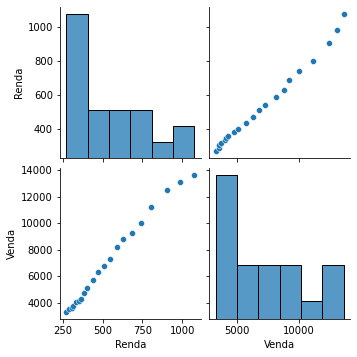

In [50]:
# Mostra a correção entre as variáveis
sns.pairplot(df)

In [51]:
# Importa as Bibliotecas
import statsmodels.api as sm
from statsmodels.formula.api import ols

# Regressão - Variável Independente Renda
model_4 = ols('Y ~ X', df4).fit()
print(model_4.summary())

                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.836
Model:                            OLS   Adj. R-squared:                  0.831
Method:                 Least Squares   F-statistic:                     187.9
Date:                Mon, 21 Nov 2022   Prob (F-statistic):           4.47e-16
Time:                        21:25:43   Log-Likelihood:                 7.0533
No. Observations:                  39   AIC:                            -10.11
Df Residuals:                      37   BIC:                            -6.780
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    -11.5266      0.841    -13.699      0.0

In [52]:
from statsmodels.stats.stattools import durbin_watson

#realiza o teste Durbin-Watson
durbin_watson(model_4.resid)

1.1160394251564412

In [53]:
X1 = [52.22, 52.31, 51.72, 51.35, 51.65, 56.13, 54.57, 54.56, 55.01, 55.39, 55.65, 44.85, 48.76, 48.96, 49.47, 49.23, 49.26, 49.30, 49.26, 49.20, 55.55, 53.89, 53.72, 53.80, 54.14, 54.52, 48.62, 50.63, 50.48, 50.38, 50.57, 50.52, 50.40, 50.15, 50.57, 50.18, 50.36, 50.63]
Y1 = [0.416872252, 0.513804272, -0.576463762, 0.236254623, 0.035288853, 0.510212673, 0.353389228, 0.430615483, 0.52942427, 0.493324756, 0.53693017, -1.225044925, -0.370236918, -0.419326033, -0.423236497, -0.193997718, -0.212737962, -0.481190228, -0.119937088, -0.173108943, 0.41212537, 0.228356188, 0.195337598, 0.082610937, 0.348653513, 0.353220835, -0.498198489, -0.127104793, -0.066318895, -0.191120411, -0.258268747, -0.15326441, -0.307241882, -0.170613719, -0.11927325, -0.185458264, -0.056590336, -0.105260278]
df4b = pd.DataFrame(list(zip(X1, Y1)), columns =['X1','Y1'])       
print(df4b)

       X1        Y1
0   52.22  0.416872
1   52.31  0.513804
2   51.72 -0.576464
3   51.35  0.236255
4   51.65  0.035289
5   56.13  0.510213
6   54.57  0.353389
7   54.56  0.430615
8   55.01  0.529424
9   55.39  0.493325
10  55.65  0.536930
11  44.85 -1.225045
12  48.76 -0.370237
13  48.96 -0.419326
14  49.47 -0.423236
15  49.23 -0.193998
16  49.26 -0.212738
17  49.30 -0.481190
18  49.26 -0.119937
19  49.20 -0.173109
20  55.55  0.412125
21  53.89  0.228356
22  53.72  0.195338
23  53.80  0.082611
24  54.14  0.348654
25  54.52  0.353221
26  48.62 -0.498198
27  50.63 -0.127105
28  50.48 -0.066319
29  50.38 -0.191120
30  50.57 -0.258269
31  50.52 -0.153264
32  50.40 -0.307242
33  50.15 -0.170614
34  50.57 -0.119273
35  50.18 -0.185458
36  50.36 -0.056590
37  50.63 -0.105260


In [55]:
# Importa as Bibliotecas
import statsmodels.api as sm
from statsmodels.formula.api import ols

# Regressão - Variável Independente Renda
model_4b = ols('Y1 ~ X1', df4b).fit()
print(model_4b.summary())

                            OLS Regression Results                            
Dep. Variable:                     Y1   R-squared:                       0.804
Model:                            OLS   Adj. R-squared:                  0.798
Method:                 Least Squares   F-statistic:                     147.5
Date:                Mon, 21 Nov 2022   Prob (F-statistic):           2.70e-14
Time:                        21:43:50   Log-Likelihood:                 13.272
No. Observations:                  38   AIC:                            -22.54
Df Residuals:                      36   BIC:                            -19.27
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -7.0580      0.580    -12.167      0.0

In [56]:
from statsmodels.stats.stattools import durbin_watson

#realiza o teste Durbin-Watson
durbin_watson(model_4b.resid)

2.358879849101729